In [75]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.colors as colors

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')

In [76]:
cd C:\Users\tr432\Downloads\filter_GutLungAxis_Week2

C:\Users\tr432\Downloads\filter_GutLungAxis_Week2


In [77]:
df_tax = pd.read_csv('gg2_phylum_table.tsv', sep='\t', skiprows=1, index_col='#OTU ID')
df_tax['Total'] = df_tax.sum(axis=1)
df_tax = df_tax.sort_values('Total', ascending=False)

meta = pd.read_csv('C:/Users/tr432/Downloads/filter_GutLungAxis_Control/RUN45_Metadata_GutLungAxis.txt', sep='\t')  ## csv일땐 sep='\t' 지워도 됨

print(df_tax.head(3))
print(meta.head(3))

                                    C01-2w   C02-2w   C03-2w   C09-2w  \
#OTU ID                                                                 
d__Bacteria;p__Pseudomonadota        687.0    252.0    341.0    789.0   
d__Bacteria;p__Bacillota_A_368345  32568.0  48836.0  18550.0  49410.0   
d__Bacteria;p__Bacillota_I         24425.0  16458.0  23664.0  40099.0   

                                    C10-2w   C11-2w   V01-2w   V02-2w  \
#OTU ID                                                                 
d__Bacteria;p__Pseudomonadota       1057.0    182.0  61787.0  69042.0   
d__Bacteria;p__Bacillota_A_368345  71464.0  67444.0     87.0     82.0   
d__Bacteria;p__Bacillota_I         15889.0  13885.0    107.0    138.0   

                                    V03-2w   V04-2w   V05-2w   V06-2w  \
#OTU ID                                                                 
d__Bacteria;p__Pseudomonadota      65878.0  63219.0  73474.0  67529.0   
d__Bacteria;p__Bacillota_A_368345    116.0     99

In [78]:
mapping = dict(zip(meta['#SampleID'].astype(str), meta['Group'].astype(str)))

df_tax2 = df_tax.copy()
df_tax2.columns = [mapping.get(c, None) for c in df_tax.columns[0:]]

df_tax2 = df_tax2.loc[:, [c for c in df_tax2.columns if c is not None]]

grouped = df_tax2.set_index(df_tax2.index).T.groupby(level=0).mean().T

grouped['Total'] = df_tax['Total']

grouped

,Control,VNAM,Total
#OTU ID,,,
d__Bacteria;p__Pseudomonadota,551.333333,63913.7,642445.0
d__Bacteria;p__Bacillota_A_368345,48045.333333,123.5,289507.0
d__Bacteria;p__Bacillota_I,22403.333333,5320.7,187627.0
d__Bacteria;p__Bacteroidota,27809.166667,223.1,169086.0
d__Bacteria;p__Verrucomicrobiota,2236.833333,13.6,13557.0
d__Bacteria;p__Bacillota_B_370539,594.333333,0.0,3566.0
d__Bacteria;p__Deferribacterota,530.333333,2.3,3205.0
d__Bacteria;p__Actinomycetota,360.000000,50.9,2669.0
d__Bacteria;p__Desulfobacterota_G_459543,157.166667,21.7,1160.0


In [79]:
for col in grouped.columns:
    print(col, sum(grouped[col]))

Control 102777.66666666667
VNAM 69689.5
Total 1313561.0


In [80]:
grouped.reset_index(inplace=True)
grouped

#grouped.to_csv("rel_gg2_genus_table_grouped.tsv", sep='\t', index=False)

,#OTU ID,Control,VNAM,Total
0,d__Bacteria;p__Pseudomonadota,551.333333,63913.7,642445.0
1,d__Bacteria;p__Bacillota_A_368345,48045.333333,123.5,289507.0
2,d__Bacteria;p__Bacillota_I,22403.333333,5320.7,187627.0
3,d__Bacteria;p__Bacteroidota,27809.166667,223.1,169086.0
4,d__Bacteria;p__Verrucomicrobiota,2236.833333,13.6,13557.0
5,d__Bacteria;p__Bacillota_B_370539,594.333333,0.0,3566.0
6,d__Bacteria;p__Deferribacterota,530.333333,2.3,3205.0
7,d__Bacteria;p__Actinomycetota,360.000000,50.9,2669.0
8,d__Bacteria;p__Desulfobacterota_G_459543,157.166667,21.7,1160.0
9,d__Bacteria;__,86.000000,11.5,631.0


In [81]:
new_cols = grouped['#OTU ID'].str.split(';', expand=True)
new_cols.columns = ['Kingdom', 'Phylum', 
#                    'Class', 'Order', 'Family', 
#                    'Genus'
                    ]

df = pd.concat([new_cols, grouped], axis=1)
df = df.drop(columns=['#OTU ID'])

## 원하는 taxa level + 그룹명만 가져옴
cols = ['Phylum', 
#        'Family', 
#        'Genus'
        ] + df.columns[2:].tolist()  #Edit: taxon level에 해당하는 숫자 입력하면 됨
df = df[cols]

df = df.replace('__', '_', regex=True)

df

,Phylum,Control,VNAM,Total
0,p_Pseudomonadota,551.333333,63913.7,642445.0
1,p_Bacillota_A_368345,48045.333333,123.5,289507.0
2,p_Bacillota_I,22403.333333,5320.7,187627.0
3,p_Bacteroidota,27809.166667,223.1,169086.0
4,p_Verrucomicrobiota,2236.833333,13.6,13557.0
5,p_Bacillota_B_370539,594.333333,0.0,3566.0
6,p_Deferribacterota,530.333333,2.3,3205.0
7,p_Actinomycetota,360.000000,50.9,2669.0
8,p_Desulfobacterota_G_459543,157.166667,21.7,1160.0
9,_,86.000000,11.5,631.0


In [82]:
df3 = df.copy()
df3['Phylum'] = df['Phylum'].str.replace(r'^p_', '', regex=True)
#df3['Family'] = df['Family'].str.replace(r'^f_', '', regex=True)
#df3['Genus']  = df['Genus'] .str.replace(r'^g_', '', regex=True)

df3

,Phylum,Control,VNAM,Total
0,Pseudomonadota,551.333333,63913.7,642445.0
1,Bacillota_A_368345,48045.333333,123.5,289507.0
2,Bacillota_I,22403.333333,5320.7,187627.0
3,Bacteroidota,27809.166667,223.1,169086.0
4,Verrucomicrobiota,2236.833333,13.6,13557.0
5,Bacillota_B_370539,594.333333,0.0,3566.0
6,Deferribacterota,530.333333,2.3,3205.0
7,Actinomycetota,360.000000,50.9,2669.0
8,Desulfobacterota_G_459543,157.166667,21.7,1160.0
9,_,86.000000,11.5,631.0


In [83]:
df4 = df3.copy()

df4.head(25)

,Phylum,Control,VNAM,Total
0,Pseudomonadota,551.333333,63913.7,642445.0
1,Bacillota_A_368345,48045.333333,123.5,289507.0
2,Bacillota_I,22403.333333,5320.7,187627.0
3,Bacteroidota,27809.166667,223.1,169086.0
4,Verrucomicrobiota,2236.833333,13.6,13557.0
5,Bacillota_B_370539,594.333333,0.0,3566.0
6,Deferribacterota,530.333333,2.3,3205.0
7,Actinomycetota,360.000000,50.9,2669.0
8,Desulfobacterota_G_459543,157.166667,21.7,1160.0
9,_,86.000000,11.5,631.0


In [84]:
df5 = df4[
    df4['Phylum'].notna() &
    ~df4['Phylum'].str.strip().isin(['', '_'])
]

df5.head(25)

,Phylum,Control,VNAM,Total
0,Pseudomonadota,551.333333,63913.7,642445.0
1,Bacillota_A_368345,48045.333333,123.5,289507.0
2,Bacillota_I,22403.333333,5320.7,187627.0
3,Bacteroidota,27809.166667,223.1,169086.0
4,Verrucomicrobiota,2236.833333,13.6,13557.0
5,Bacillota_B_370539,594.333333,0.0,3566.0
6,Deferribacterota,530.333333,2.3,3205.0
7,Actinomycetota,360.000000,50.9,2669.0
8,Desulfobacterota_G_459543,157.166667,21.7,1160.0
10,Methanobacteriota_A_1229,3.833333,2.8,51.0


In [85]:
## Phylum Level - Relative Abundance로 변환 후 정렬


df6 = df5.copy()

num_cols = df6.columns[1:]  #Edit
df6[num_cols] = df6[num_cols].div(df6[num_cols].sum(axis=0), axis=1)  #Edit: 이 줄을 주석처리하면 절대 풍부도 나타낼 수 있음 -> rev_26.02.16: Absolute Abundance (x) / Read Counts (o)


# 2-1. 상위 n개 기준: 각 taxon 의 전체 합
df6['rel_feature_sum'] = df6[num_cols].sum(axis=1)

# 2-2. Others 로 보낼 문자열 패턴 지정
banned_prefix = ['CAG', 'COE', 'UBA', 'HUN', 'UMGS', 'C-53']  #Edit: 바로 위 셀의 head(25) 결과 보고 직접 판단

# Phylum 기준으로 패턴 포함 여부
mask_banned = df6['Phylum'].str.upper().str.startswith(tuple(banned_prefix))

# 2-3. 상위 n개 (banned 는 제외하고 뽑기)
df_allowed = df6.loc[~mask_banned]
df_allowed = df_allowed.sort_values('Total', ascending=False)
top_idx = df_allowed.index[:8]  #Edit: 상위 몇개만 가져올지 선택

# 최종적으로 Others 로 갈 행
mask_top = df6.index.isin(top_idx)
mask_others = ~mask_top | mask_banned   # top n 밖이거나, banned 인 것들

# 2-4. 상위 n개만 남기기
df_top = df6.loc[~mask_others].copy()
df_top = df_top.sort_values('Total', ascending=False)
print(df_top['Control'].sum())
print(df_top['VNAM'].sum())

# 2-5. Others 행 만들기 (나머지 합)
others_vals = df6.loc[mask_others, num_cols].sum()
others_row = {'Phylum': 'Others', 
#              'Family': 'Others', 
#              'Genus': 'Others'
              }
for c in num_cols:
    others_row[c] = others_vals[c]

df_final = pd.concat([df_top, pd.DataFrame([others_row])],
                     ignore_index=True)

# rel_feature_sum 컬럼은 필요 없으면 제거
#df_final = df_final.drop(columns=['rel_feature_sum'])
print(df_final['Control'].sum())
print(df_final['VNAM'].sum())

#df6.head(25)
#df_allowed.head(15)
#df_top
df_final

0.9984321999513105
0.9995665776859265
0.9999999999999999
0.9999999999999998


,Phylum,Control,VNAM,Total,rel_feature_sum
0,Pseudomonadota,0.005369,0.917272,0.489322,1.411963
1,Bacillota_A_368345,0.467860,0.001772,0.220505,0.690137
2,Bacillota_I,0.218161,0.076361,0.142907,0.437430
3,Bacteroidota,0.270803,0.003202,0.128785,0.402790
4,Verrucomicrobiota,0.021782,0.000195,0.010326,0.032303
5,Bacillota_B_370539,0.005788,0.000000,0.002716,0.008504
6,Deferribacterota,0.005164,0.000033,0.002441,0.007638
7,Actinomycetota,0.003506,0.000731,0.002033,0.006269
8,Others,0.001568,0.000433,0.000966,NaN


In [86]:
df_final_genus = df_final.drop(columns=['rel_feature_sum'])
#df_final_family = df_final2.drop(columns=['rel_feature_sum'])
#df_final_phylum = df_final3.drop(columns=['rel_feature_sum'])

#df_final_genus.to_csv("df_final_genus.tsv", sep='\t', index=False)
#df_final_family.to_csv("df_final_family.tsv", sep='\t', index=False)
#df_final_phylum.to_csv("df_final_phylum.tsv", sep='\t', index=False)

In [87]:
cols = ['Phylum'] + df_final_genus.columns[1:3].tolist()  #Edit: [(Taxon level에 해당하는 숫자-1):(+그룹 수)]
df_barplot = df_final_genus[cols]
df_barplot = df_barplot.set_index(df_barplot.columns[0])
df_barplot = df_barplot.transpose()

df_barplot

Phylum,Pseudomonadota,Bacillota_A_368345,Bacillota_I,Bacteroidota,Verrucomicrobiota,Bacillota_B_370539,Deferribacterota,Actinomycetota,Others
Control,0.005369,0.467860,0.218161,0.270803,0.021782,0.005788,0.005164,0.003506,0.001568
VNAM,0.917272,0.001772,0.076361,0.003202,0.000195,0.000000,0.000033,0.000731,0.000433


In [88]:
GutLungAxis = colors.ListedColormap(["#C96E7B","#4A7EA8","#D9A45A","#4F9A7A","#E0B5A0",
                                     "#6A87B5","#C98FCA","#5E8E91","#C3B86D","#4E9260",
                                     "#D48D6F","#5E6E8A","#B0778A","#6E7F73","#BFA27C",
                                     "#7B87A0","#A97F65","#8E8F9A","#CBBFB2","#F3EEE7",
                                     "#DDDDDD"])

GutLungAxis_vivid = colors.ListedColormap(["#EF404A","#00A7EB","#FFD400","#80B463","#F2728C",
                                           "#556C99","#9E7EB9","#4EB8B9","#F79552","#4F9472",
                                           "#F9C0C7","#FFCC4E","#D5E05B","#81D3EB","#B0DFDB",
                                           "#BBB8DC","#A7A9AC","#C69AB0","#E3DED0","#F3EEE7",
                                           "#DDDDDD"])

wine_soft_21 = colors.ListedColormap(["#8C2744","#B33C4F","#CC5664","#E06C74","#EB8586",
                                      "#F29B94","#F5B3A9","#F8C9BC","#9A3E63","#BF6783",
                                      "#D9889A","#EFA3B8","#C55A70","#E06E93","#D89A5C",
                                      "#E3B66D","#B88257","#A07166","#D4B4AF","#F6EBE4",
                                      "#DDDDDD"])

darkpurple_axis_rosegold_21 = colors.ListedColormap(["#5A255D","#742C6E","#8A2F7C","#A13788","#B55297",
                                                     "#C66AA7","#D282B8","#B5738F","#C5859F","#D79CAF",
                                                     "#E4B6C3","#8C6BC5","#A080D6","#B39BE3","#C8B3EE",
                                                     "#C88A5A","#E0A96D","#F2C48C","#E7D4F2","#F2E7FA",
                                                     "#DDDDDD"])

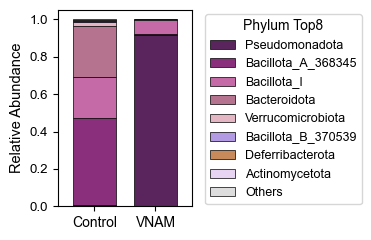

In [89]:
## Phylum Level - Top 8

df_barplot.plot(kind='bar', stacked=True,figsize=(3.9, 2.5), colormap=darkpurple_axis_rosegold_21, edgecolor='k', linewidth=0.5, width=0.7)  ## Pastel1은 9개 색 제공 -> 그 이상은 색깔 돌려막기
plt.xticks(ticks=range(len(df_barplot.index)), labels=['Control', 'VNAM'], rotation=0, fontsize=10)  #Edit: plot에 표시될 이름으로 labels 지정
plt.yticks(fontsize=9.5)
plt.xlabel('')
plt.ylabel('Relative Abundance', fontsize=10.5)  #Edit
plt.title('')
plt.legend(title='Phylum Top8', bbox_to_anchor=(1.05, 1.01), fontsize=9)  #Edit: legend 위치에 맞춰서 조정
plt.tight_layout()
plt.savefig('phylum_rel_top8_v2.png', dpi=500, bbox_inches='tight')
plt.show()